# Desafio Praso: Previsão de Risco de Inadimplência

## 1. O que é o projeto
Este projeto é um desafio prático da disciplina de Machine Learning em parceria com a Praso, uma startup que atua facilitando o ciclo de caixa de pequenos varejistas. 

Muitos empreendedores sofrem com a demora para transformar as compras de estoque em vendas (receita). A Praso resolve essa dor oferecendo crédito instantâneo e desburocratizado. Nosso papel neste trabalho é desenvolver o "motor" por trás dessa decisão: um modelo preditivo capaz de estimar a probabilidade de um cliente ficar inadimplente. A qualidade da nossa solução será medida pela capacidade de ordenar bem os clientes em relação ao risco, utilizando a métrica ROC-AUC.

## 2. O que a gente pretende fazer
O desenvolvimento seguirá as etapas fundamentais de um pipeline de Ciência de Dados, conectando a teoria da disciplina com a necessidade de negócio da Praso:

* **Análise Exploratória e Pré-processamento:** Investigar a fundo a base de dados para entender o comportamento das variáveis, tratar valores nulos, lidar com possíveis outliers e resolver o desbalanceamento das classes.
* **Feature Engineering:** Transformar os dados brutos em informações úteis. Faremos a conversão de intervalos de idade do CNPJ para valores contínuos, extrairemos variáveis booleanas (como presença ou não em aplicativos de delivery) e agruparemos dados complexos, como os códigos CNAE e a lista de credores.
* **Modelagem Preditiva:** Desenvolveremos duas abordagens complementares: um "Modelo de Aplicação" (focado em novos clientes, usando dados públicos e da Serasa) e um "Modelo Comportamental" (para clientes recorrentes, agregando o histórico de compras e atrasos).
* **Avaliação e Discussão:** Vamos treinar, otimizar (tunar hiperparâmetros) e comparar pelo menos três algoritmos diferentes, finalizando com uma discussão sobre as limitações e como nossa solução seria aplicada na política de crédito real da startup.

## 3. Explicação dos Datasets
Trabalharemos com bases de dados reais (porém anonimizadas por questões de segurança), que estão divididas em dois contextos principais:

* **Dados Cadastrais e de Risco:** Focados no perfil do estabelecimento comercial no momento do cadastro. Incluem a localização, natureza jurídica, capital social e idade do CNPJ. Também trazem informações externas cruciais, como a presença digital (notas e avaliações no Google Maps e iFood) e o histórico em birôs de crédito (quantidade de negativações, protestos e perfil dos credores na Serasa). A variável alvo de inadimplência pertence a esta base.
* **Dados Comportamentais (Pedidos):** Focados no histórico de relacionamento do cliente com a Praso. Contêm o valor de cada pedido, a data de entrega e o número de dias de atraso no pagamento. Esses dados serão agregados por cliente para entendermos o padrão de pagamento de quem já compra na plataforma.

## 4. Análise Exploratória de Dados (EDA)

Antes de iniciar a modelagem preditiva, é fundamental entender a fundo o comportamento dos dados e como as características dos varejistas se relacionam com o risco de crédito na Praso. Nesta etapa, nossos principais objetivos são:

* **Inspeção de Qualidade:** Identificar e tratar valores faltantes (nulos), duplicatas e possíveis *outliers* que possam prejudicar a inteligência do modelo.
* **Avaliação da Variável Alvo:** Analisar o grau de desbalanceamento da classe `inadimplente` (0 = Não, 1 = Sim) para guiar nossas métricas de avaliação (como ROC-AUC).
* **Análise Bivariada e Hipóteses:** Relacionar variáveis cadastrais (ex: negativações na Serasa, segmento, idade do CNPJ) e comportamentais (ex: média de atraso nos pedidos) com a taxa de inadimplência, gerando *insights* e preparando o terreno para a *Feature Engineering*.

### 4.1. Configuração Inicial e Carregamento dos Dados

**Objetivo da Análise:** 
Preparar o nosso ambiente de trabalho. Aqui, importaremos as bibliotecas fundamentais para a manipulação e visualização dos dados (`pandas`, `matplotlib` e `seaborn`). Em seguida, faremos a leitura das duas bases fornecidas pela Praso: a tabela de cadastro/risco dos clientes e a tabela de histórico comportamental de pedidos.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split



sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df_clientes = pd.read_csv('credito_aplicacao_clientes_final.csv') 
df_pedidos = pd.read_csv('credito_comportamental_pedidos_final.csv')

### 4.2. Análise da Variável Alvo: Verificando o Desbalanceamento

**Objetivo da Análise:** 
Entender a distribuição da nossa variável dependente (`inadimplente`). O desafio pede uma atenção especial ao desbalanceamento das classes, pois em problemas de concessão de crédito, é comum termos muito mais "bons pagadores" (0) do que "maus pagadores" (1). Compreender essa proporção ditará a necessidade de técnicas de balanceamento mais à frente e justifica o uso do **ROC-AUC** como métrica principal de avaliação.

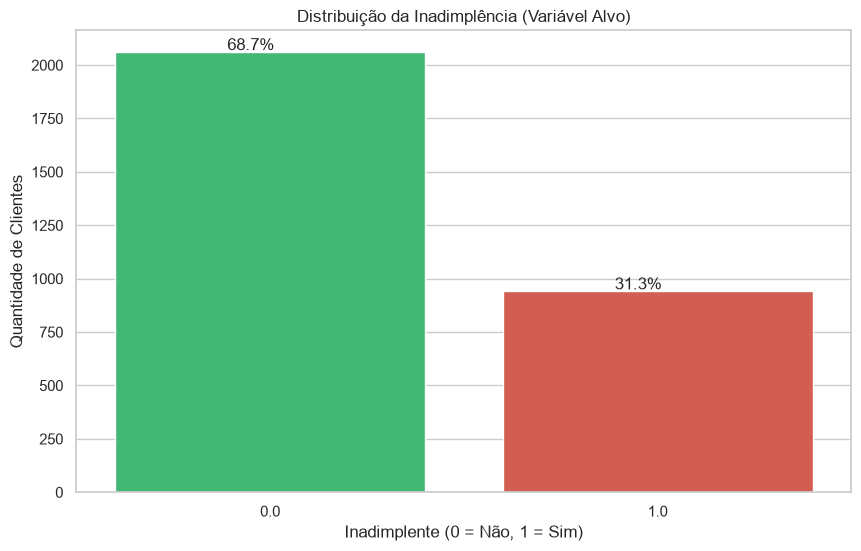

In [12]:
ax = sns.countplot(data=df_clientes, x='inadimplente', palette=['#2ecc71', '#e74c3c'],hue='inadimplente', legend=False)
plt.title('Distribuição da Inadimplência (Variável Alvo)')
plt.xlabel('Inadimplente (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Clientes')


total = len(df_clientes)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 10
    ax.annotate(percentage, (x, y), ha='center')

plt.show()

### Análise dos Resultados: Distribuição da Variável Alvo

Com base no gráfico gerado, identificamos o comportamento da nossa variável alvo (`inadimplente`) no dataset:

* **Adimplentes (0.0):** Representam a maioria da base, totalizando **68,7%** dos clientes (bons pagadores).
* **Inadimplentes (1.0):** Representam a minoria, correspondendo a **31,3%** dos clientes.

**Principais Insights e Implicações para a Modelagem:**

1. **Desbalanceamento Moderado:** O dataset apresenta um desbalanceamento aproximado de 2:1. Embora seja comum em problemas de crédito ter mais "bons" do que "maus" pagadores, uma taxa de inadimplência na casa dos 31% é considerada alta para padrões de mercado tradicionais. Isso ilustra perfeitamente o cenário da Praso: ao desburocratizar o crédito para pequenos varejistas sem exigir histórico extenso, a startup assume um risco maior, tornando a assertividade do nosso modelo preditivo vital para a saúde financeira do negócio.
2. **A "Armadilha" da Acurácia:** Devido a esse desbalanceamento, a métrica de Acurácia tradicional será ilusória. Se criarmos um modelo "burro" que simplesmente preveja que *nenhum* cliente ficará inadimplente (chutando 0 para todos), ele terá quase 69% de acerto. Isso mascararia o nosso real problema: identificar os maus pagadores.
3. **Validação do ROC-AUC:** Esse cenário comprova a necessidade de utilizarmos o **ROC-AUC** como métrica principal de avaliação, conforme exigido no desafio. O ROC-AUC mede a capacidade do modelo de distinguir entre as duas classes e ordená-las corretamente em um *score* de risco, o que é imune ao desbalanceamento das proporções.
4. **Estratégias Futuras:** Na etapa de modelagem, precisaremos testar estratégias para lidar com essa diferença de representatividade, como o uso de pesos balanceados nos algoritmos (ex: `class_weight='balanced'`) ou técnicas de reamostragem (como o SMOTE ou undersampling).

### 4.3. Mapeamento de Dados Faltantes

**Objetivo da Análise:** 
Identificar o volume e a localização dos dados faltantes em nossa base. Segundo o material do desafio, na Praso, a ausência de um dado pode ser uma informação valiosa por si só. Por exemplo, a ausência de informações nas variáveis `ifood_contagem_avaliacoes` ou `google_maps_avaliacao` nos diz que o cliente não possui presença nessas plataformas. Mapear isso agora é o primeiro passo para criarmos variáveis booleanas (Tem/Não tem) na fase de *Feature Engineering*.

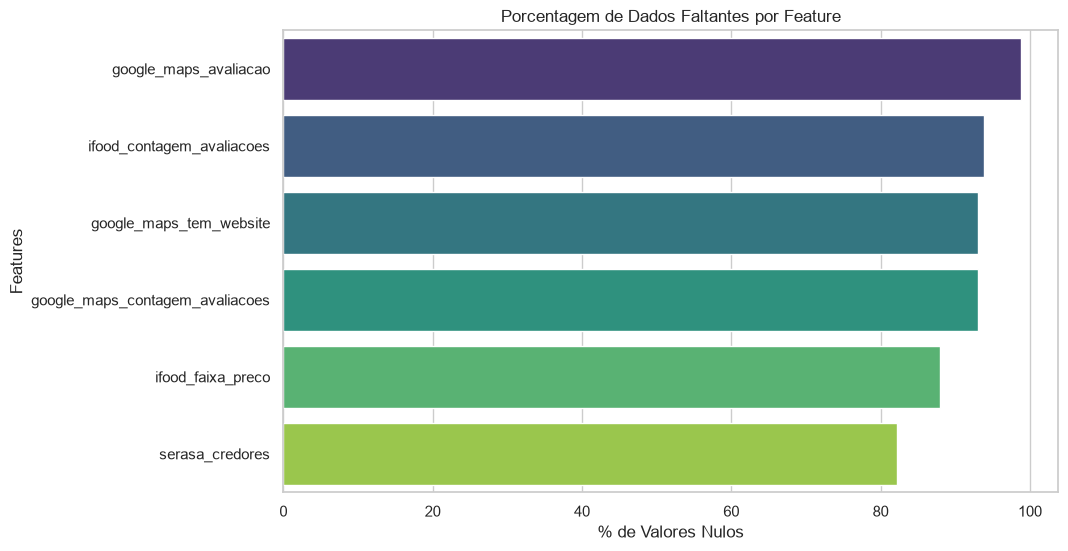

In [13]:
nulos_percentual = (df_clientes.isnull().sum() / len(df_clientes)) * 100
nulos_percentual = nulos_percentual[nulos_percentual > 0].sort_values(ascending=False)

if not nulos_percentual.empty:
    sns.barplot(x=nulos_percentual.values, y=nulos_percentual.index, palette='viridis', legend=False, hue=nulos_percentual.index,)
    plt.title('Porcentagem de Dados Faltantes por Feature')
    plt.xlabel('% de Valores Nulos')
    plt.ylabel('Features')
    plt.show()
else:
    print("Nenhum dado faltante encontrado!")

### Análise dos Resultados: Tratamento de Dados Faltantes (Valores Nulos)

O gráfico acima revela que todas as colunas que apresentam valores nulos em nossa base possuem uma taxa de ausência altíssima (acima de 80%). Observando as variáveis afetadas, notamos que elas pertencem a três categorias principais de fontes externas: **Google Maps**, **iFood** e **Serasa**.

**Principais Insights e Estratégia de Feature Engineering:**

1. **Ausência Estrutural (Missing Not at Random):**
   * Se um cliente tem valor nulo em `Maps_avaliacao`, significa que o estabelecimento não possui presença mapeada no Google.
   * Se tem nulo em `ifood_contagem_avaliacoes`, o cliente não está cadastrado no app de delivery.
   * Se `serasa_credores` é nulo, significa que o cliente não possui dívidas registradas com outras empresas naquele momento.

2. **Criação de Variáveis Booleanas (Flags):** Conforme sugerido nas diretrizes do desafio da Praso, não vamos excluir essas colunas. Em vez disso, usaremos a etapa de *Feature Engineering* para criar novas variáveis booleanas. 
   * Exemplo: Criar a variável `presenca_ifood` (onde 1 = tem dados no iFood; 0 = valor nulo). 
   * A hipótese de negócio aqui é clara: estabelecimentos com presença digital ativa (iFood, Google Maps) tendem a ser mais estruturados e, possivelmente, apresentam menor risco de crédito.

3. **Tratamento dos Valores Originais:** Após criarmos as variáveis booleanas para indicar a "presença", precisaremos preencher os valores vazios nas colunas originais para que os algoritmos de funcionem corretamente. Podemos preencher numéricos com `-1` (indicando ausência) e categóricos com a string `"Desconhecido"`.

### 4.4. Segmento do Cliente e Risco

**Objetivo da Análise:** 
Analisar como as características cadastrais e o histórico de crédito prévio se relacionam com o fato de o cliente não pagar a Praso. Conforme sugerido no escopo do projeto, vamos comparar as taxas de inadimplência entre os diferentes `segmento_cliente` (ex: Padarias vs. Hotéis) e verificar se restrições nos birôs (como `serasa_socio_tem_negativacao`) são, de fato, fortes indicativos.

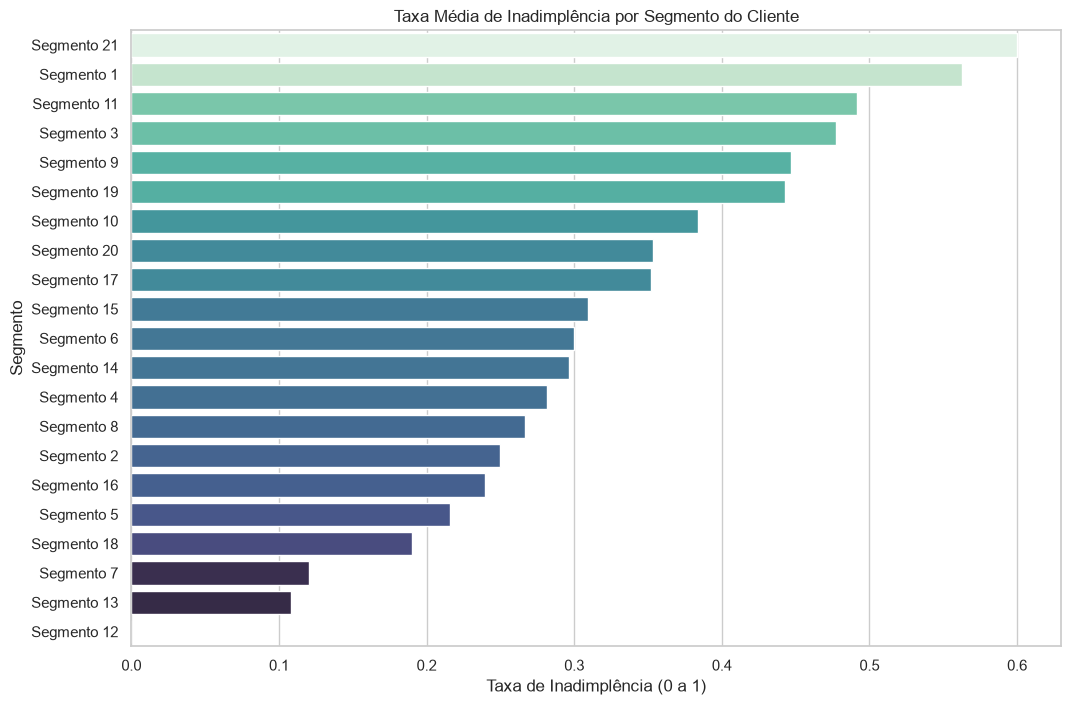

In [14]:
segmento_inadimplencia = df_clientes.groupby('segmento_cliente')['inadimplente'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=segmento_inadimplencia, x='inadimplente', y='segmento_cliente', palette='mako', hue='inadimplente', legend=False)
plt.title('Taxa Média de Inadimplência por Segmento do Cliente')
plt.xlabel('Taxa de Inadimplência (0 a 1)')
plt.ylabel('Segmento')
plt.show()

### Análise dos Resultados: Taxa de Inadimplência por Segmento

O gráfico de barras ilustra a taxa média de inadimplência agrupada pelos 21 segmentos de clientes anonimizados da base. Fica evidente que o nicho de atuação do varejista tem um impacto direto e drástico na probabilidade de calote.

**Principais Insights e Implicações para a Modelagem:**

1. **Disparidade Extrema de Risco:** Existe uma variação massiva de risco entre as pontas. 
   * Os **Segmentos 21 e 1** são os mais críticos, apresentando taxas de inadimplência alarmantes de aproximadamente 60% e 56%, respectivamente. Mais da metade dos clientes desses grupos não pagam.
   * Em contrapartida, os **Segmentos 12, 13 e 7** são extremamente seguros. O Segmento 12 beira o 0% de inadimplência, enquanto o 13 e o 7 ficam na faixa dos 10% a 13%.
2. **Alto Poder Preditivo:** Por apresentar tanta variância em relação à variável alvo, `segmento_cliente` será uma das *features* (variáveis) mais importantes para o nosso algoritmo. O modelo facilmente aprenderá a penalizar o *score* de crédito do Segmento 21 e beneficiar o do Segmento 12.
3. **Atenção ao Overfitting (Estratégia de Modelagem):** Como temos 21 categorias numéricas anonimizadas, precisaremos converter esses dados adequadamente (por exemplo, usando *One-Hot Encoding* ou *Target Encoding*). Contudo, devemos verificar se os segmentos nos extremos (como o 12 e o 21) possuem um volume de clientes representativo. Se o Segmento 12 tiver apenas 2 clientes na base toda, essa taxa de 0% pode ser uma armadilha estatística (*overfitting*).
4. **Implicações Práticas para a Praso:** Do ponto de vista de negócios, essas informações permitem a criação de **políticas de crédito segmentadas**. A Praso poderia, por exemplo, exigir um fiador ou reduzir o limite inicial de crédito para clientes do Segmento 21, enquanto libera crédito pré-aprovado mais elástico para o Segmento 13, melhorando a experiência do bom pagador.

### 4.5. Impacto de Sócios Negativados na Serasa

**Objetivo da Análise:**
Nesta etapa, vamos investigar a relação direta entre o histórico de crédito dos proprietários (Pessoa Física) e o risco da empresa (Pessoa Jurídica). A variável `serasa_socio_tem_negativacao` é uma flag booleana. A nossa hipótese de negócio aqui é clara: empreendedores que possuem restrições ativas em seu próprio CPF (na Serasa) tendem a apresentar um risco de inadimplência consideravelmente maior quando buscam crédito para o seu CNPJ na Praso. Vamos validar isso visualmente.

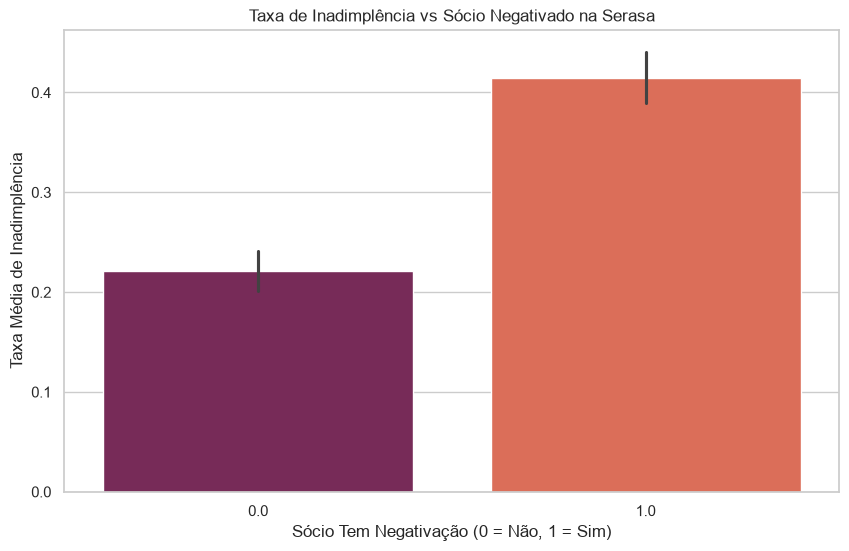

In [15]:
sns.barplot(data=df_clientes, x='serasa_socio_tem_negativacao', y='inadimplente', palette='rocket', legend= False, hue ='serasa_socio_tem_negativacao' )
plt.title('Taxa de Inadimplência vs Sócio Negativado na Serasa')
plt.xlabel('Sócio Tem Negativação (0 = Não, 1 = Sim)')
plt.ylabel('Taxa Média de Inadimplência')
plt.show()

### Análise dos Resultados: Sócio Negativado na Serasa

O gráfico acima cruza a taxa média de inadimplência da empresa com o fato de algum de seus sócios possuir uma negativação ativa junto à Serasa. 

**Principais Insights e Implicações para a Modelagem:**

1. **Validação da Hipótese de Contágio de Risco:** A nossa hipótese inicial foi fortemente confirmada. Quando o sócio **não tem** negativação (0.0), a taxa de inadimplência da empresa na Praso fica um pouco acima dos 20%. No entanto, quando o sócio **tem** uma negativação (1.0), essa taxa praticamente dobra, ultrapassando a marca dos 40%.
2. **Mistura de PFs e PJs no Pequeno Varejo:** Esse comportamento é muito característico do pequeno varejo brasileiro. Na prática financeira, o caixa do dono (Pessoa Física) muitas vezes se confunde com o caixa da empresa (Pessoa Jurídica). Se o empreendedor já está inadimplente em suas contas pessoais, a probabilidade de o CNPJ também não conseguir honrar seus compromissos com fornecedores (como a Praso) aumenta drasticamente.
3. **Poder da Variável no Modelo:** A variável `serasa_socio_tem_negativacao` provou ser um excelente preditor (uma *feature* de alto peso). Como ela já está em formato booleano (0 e 1) e apresenta uma separação estatística clara (indicada pelos curtos intervalos de confiança que não se cruzam), ela poderá ser injetada quase diretamente no nosso modelo de *Machine Learning*.
4. **Impacto na Aplicação de Negócio:** Na política de crédito da Praso (para o Modelo de Aplicação focado em novos clientes), essa variável pode atuar como um filtro inicial (uma regra de *cut-off*). Clientes com sócios negativados podem ter um teto de crédito inicial mais conservador até que provem um bom comportamento de pagamento nos primeiros pedidos.

### 4.6. Maturidade do Negócio vs. Risco: Avaliando as Faixas de Idade do CNPJ

**Objetivo da Análise:** 
O objetivo desta etapa é visualizar o volume de clientes dentro de cada faixa de idade e cruzar essa informação com a taxa de inadimplência média daquele grupo.

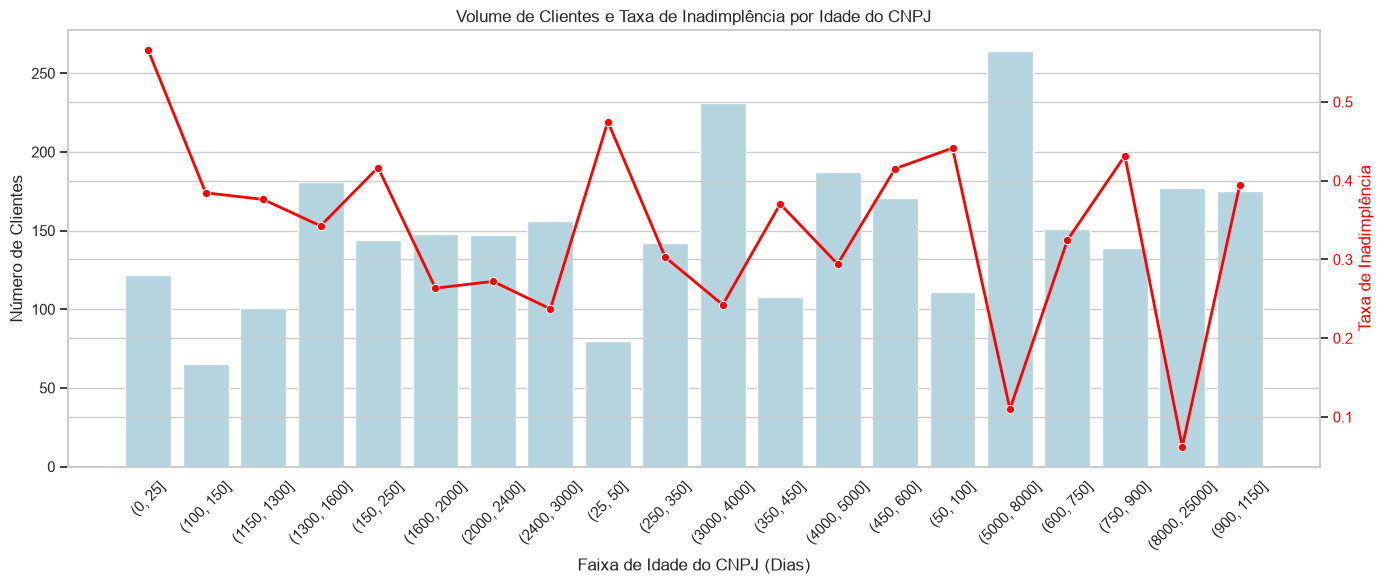

In [16]:
ordem_idade = sorted(df_clientes['idade_cnpj'].dropna().unique().tolist())

fig, ax1 = plt.subplots(figsize=(14, 6))


sns.countplot(data=df_clientes, x='idade_cnpj', order=ordem_idade, color='lightblue', ax=ax1)
ax1.set_ylabel('Número de Clientes')
ax1.set_xlabel('Faixa de Idade do CNPJ (Dias)')
plt.xticks(rotation=45)


ax2 = ax1.twinx()
taxa_idade = df_clientes.groupby('idade_cnpj')['inadimplente'].mean()[ordem_idade]
sns.lineplot(x=taxa_idade.index, y=taxa_idade.values, color='red', marker='o', ax=ax2, linewidth=2)
ax2.set_ylabel('Taxa de Inadimplência', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Volume de Clientes e Taxa de Inadimplência por Idade do CNPJ')
plt.tight_layout()
plt.show()

### Análise dos Resultados: Maturidade do Negócio vs. Risco

O gráfico misto acima sobrepõe o volume de clientes (barras) e a taxa de inadimplência (linha vermelha) agrupados pelas faixas de idade do CNPJ. 

**Principais Insights e Implicações para a Modelagem:**

1. **O Risco dos Negócios "Recém-Nascidos":** O ponto que mais chama a atenção é o extremo esquerdo do gráfico, na faixa `(0, 25]`. Empresas com menos de um mês de existência (desde a abertura na Sefaz até o cadastro na Praso) apresentam o maior pico de risco da base, com uma inadimplência que ultrapassa os 50%. Isso reflete perfeitamente a realidade do pequeno varejo: negócios em estágio inicial sofrem com alta volatilidade e falta de fluxo de caixa consolidado.
2. **Erro da Ordem Alfabética:** Ao analisar a linha de tendência, nota-se um comportamento errático (zigue-zague). Isso ocorreu porque as faixas (por estarem em formato de texto/string) foram plotadas em ordem alfabética lexicográfica (ex: o caractere "1150" foi colocado antes de "150"), e não em ordem cronológica contínua. Por conta disso, a curva real de amadurecimento do risco com o passar do tempo ficou ofuscada.
3. **Estratégia de Feature Engineering:** Conforme sugerido nas diretrizes do desafio, a melhor forma de contornar esse problema e gerar valor para o modelo de Machine Learning é realizar uma transformação desses dados. Na próxima fase, vamos converter essas categorias de texto em variáveis contínuas, extraindo o **ponto médio** de cada intervalo. Por exemplo, a faixa `(150, 250]` será transformada no número `200`. Isso corrigirá nossa ordenação e permitirá que o algoritmo entenda perfeitamente a grandeza numérica da "idade" da empresa.

### 4.7. Modelo Comportamental: Impacto do Histórico de Pedidos e Atrasos

**Objetivo da Análise:** 
Para a construção do Modelo Comportamental, o desafio exige a criação de variáveis agregadas a partir do histórico de compras. O objetivo desta célula é analisar a base `credito_comportamental_pedidos_final.csv`, extraindo métricas a nível de cliente, como o *atraso médio* e o *volume total comprado*. A ideia é verificar visualmente se clientes que atrasam os primeiros pedidos têm maior probabilidade de virar inadimplentes definitivos.

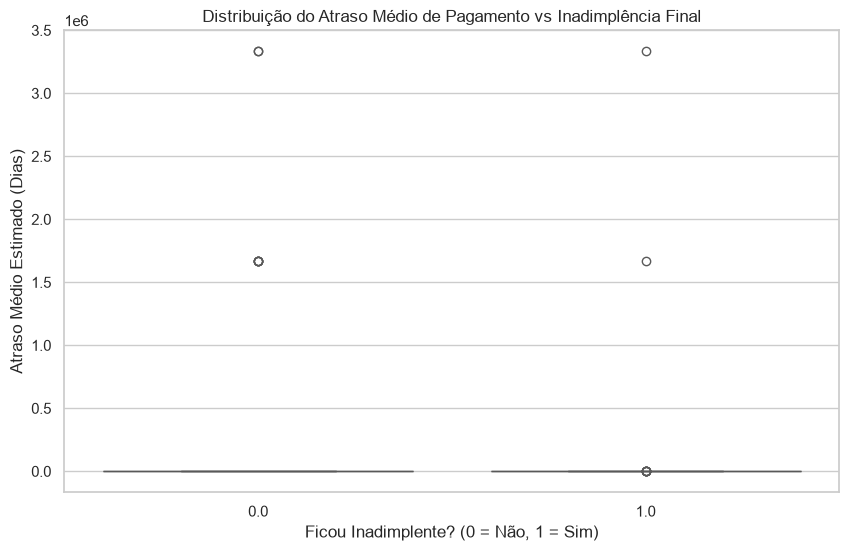

In [17]:

def extrair_ponto_medio(intervalo):
    if pd.isna(intervalo):
        return np.nan
    
    texto = str(intervalo)
    
    if ',' in texto:
        texto_limpo = texto.replace('(', '').replace('[', '').replace(']', '').replace(')', '')
        partes = texto_limpo.split(',')
        try:
            return (float(partes[0]) + float(partes[1])) / 2
        except:
            return np.nan
    try:
        return float(texto)
    except:
        return np.nan
    
def limpa_id(x):
    try:
        return str(int(float(x)))
    except:
        return str(x).strip()

df_clientes['id_cliente_clean'] = df_clientes['id_cliente'].apply(limpa_id)
df_pedidos['id_cliente_clean'] = df_pedidos['id_cliente'].apply(limpa_id)

df_pedidos['atraso_numerico'] = df_pedidos['atraso'].apply(extrair_ponto_medio)
df_pedidos['valor'] = pd.to_numeric(df_pedidos['valor'], errors='coerce')


df_comportamento = df_pedidos.groupby('id_cliente_clean').agg(
    valor_total_gasto=('valor', 'sum'),
    atraso_medio=('atraso_numerico', 'mean'),
    quantidade_pedidos=('id_pedido', 'count')
).reset_index()


df_analise_comportamento = df_clientes[['id_cliente_clean', 'inadimplente']].merge(
    df_comportamento, on='id_cliente_clean', how='inner'
)

df_plot = df_analise_comportamento.dropna(subset=['atraso_medio'])


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_plot, 
    x='inadimplente', 
    y='atraso_medio', 
    hue='inadimplente',
    palette='Set2',
    legend=False
)
plt.title('Distribuição do Atraso Médio de Pagamento vs Inadimplência Final')
plt.xlabel('Ficou Inadimplente? (0 = Não, 1 = Sim)')
plt.ylabel('Atraso Médio Estimado (Dias)')
plt.ylabel('Atraso Médio Estimado (Dias)') 
plt.show()


### Análise dos Resultados: Comportamento de Pagamento e Descoberta de Outliers

Ao gerarmos o primeiro boxplot do histórico de atrasos, nos deparamos com uma situação clássica do trabalho com dados reais: a presença de *outliers* extremos.

**Principais Insights e Implicações para a Modelagem:**

1. **Anomalias na Base de Dados:** O gráfico original revelou registros com atrasos médios na casa dos milhões de dias. Como isso é cronologicamente impossível, trata-se claramente de um artefato de erro do sistema de origem. 
2. **Impacto na Modelagem:** Descobrir isso agora é crucial. Se alimentarmos um modelo com um atraso de "3 milhões de dias", o modelo ficará totalmente enviesado.
3. **Estratégia de Limpeza:** Na próxima fase de pré-processamento, será fundamental aplicar um filtro para remover ou limitar esses valores absurdos, garantindo que o algoritmo aprenda apenas com o comportamento humano real.

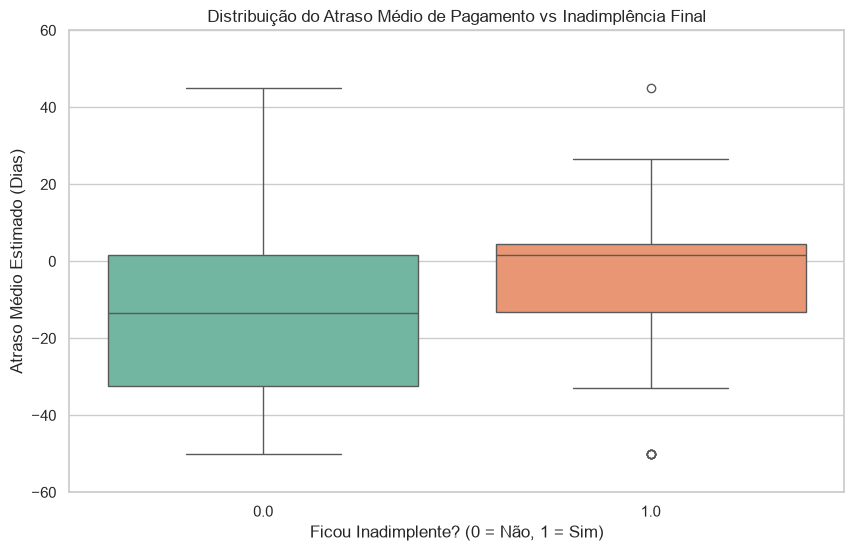

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_plot, 
    x='inadimplente', 
    y='atraso_medio', 
    hue='inadimplente',
    palette='Set2',
    legend=False
)
plt.title('Distribuição do Atraso Médio de Pagamento vs Inadimplência Final')
plt.xlabel('Ficou Inadimplente? (0 = Não, 1 = Sim)')
plt.ylabel('Atraso Médio Estimado (Dias)')
plt.ylabel('Atraso Médio Estimado (Dias)') 
plt.ylim(-60, 60)
plt.show()

### Análise dos Resultados: Comportamento Real de Pagamento

**Principais Insights e Implicações para a Modelagem:**

1. **Atraso Negativo:** Um "atraso negativo" significa que o cliente pagou o boleto antes da data de vencimento. Observando a caixa verde, a mediana está na faixa de -15 dias. O intervalo interquartil mostra que a grande maioria deles paga muito antes do prazo.
2. **O Perfil do Inadimplente:** Quando olhamos para a caixa laranja, notamos um deslocamento claro para cima. A mediana salta para perto do 0  ou ligeiramente positivo. O grupo que futuramente poderá se torna inadimplente costuma usar o prazo de crédito até o limite ou atrasa alguns dias já nas compras anteriores.
3. **Alto Poder Preditivo:** A distância visual entre as medianas prova que a variável `atraso_medio` será importante para o nosso Modelo Comportamental.

## 5. Feature Engineering: Pré-processamento e Criação de Variáveis

 
Nesta fase, vamos transformar os dados brutos em formatos matemáticos otimizados para que os algoritmos de Machine Learning consigam aprender e extrair o máximo de poder preditivo. Nosso plano de ação está dividido nas seguintes frentes:

### 5.1. Presença Digital e o Valor dos Dados Nulos
Durante a EDA, descobrimos que colunas referentes ao iFood, Google Maps e Credores possuíam altas taxas de valores nulos. Entendemos que essa ausência não é um erro do sistema, mas sim uma característica valiosa do negócio.
* **Criação de Flags Booleanas:** Vamos gerar novas variáveis binárias (ex: `flag_tem_ifood`, `flag_tem_google`, `flag_tem_credores`) onde 1 indica presença do dado e 0 indica ausência.

### 5.2. Transformação de Intervalos em Variáveis Contínuas
A idade da empresa (`idade_cnpj`) e o atraso dos pedidos vieram ofuscados em formato de intervalos de texto (ex: `(150, 250]`), o que impede o cálculo matemático direto pelos modelos.
* **Cálculo do Ponto Médio:** Atendendo a uma sugestão direta do desafio, aplicaremos uma transformação para extrair os limites desses textos e calcular o ponto médio. Por exemplo, a faixa `(150, 250]` se transformará no valor numérico contínuo `200.0`.

### 5.3. Histórico de Crédito (Serasa)
As restrições de crédito provaram ter um alto poder de separação entre bons e maus pagadores na nossa análise bivariada.
* **Contagem de Credores:** A coluna `serasa_credores` traz uma lista descritiva em texto (ex: "Alimentos e Bebidas, Distribuição"). Transformaremos isso em uma variável quantitativa (`qtd_credores`), contando o número exato de empresas distintas para as quais o cliente deve, fornecendo um termômetro claro da gravidade do endividamento.

### 5.4. Agregação Comportamental (Histórico de Pedidos)
Para viabilizar o Modelo Comportamental, cruzaremos a base de clientes com o histórico de compras.
* **Métricas Agregadas por Cliente:** Após filtrarmos dados anômalos , calcularemos o valor total gasto, a quantidade de pedidos e o atraso médio estimado, consolidando essas informações como features numéricas exclusivas de cada comprador.

In [19]:
df_clientes['idade_cnpj_numerica'] = df_clientes['idade_cnpj'].apply(extrair_ponto_medio)

df_clientes['flag_tem_ifood'] = df_clientes['ifood_contagem_avaliacoes'].notna().astype(int)
df_clientes['flag_tem_google'] = df_clientes['google_maps_avaliacao'].notna().astype(int)
df_clientes['flag_tem_credores'] = df_clientes['serasa_credores'].notna().astype(int)


def contar_credores(lista_credores):
    if pd.isna(lista_credores): return 0
    return len(str(lista_credores).split(','))

df_clientes['qtd_credores'] = df_clientes['serasa_credores'].apply(contar_credores)

df_clientes['ifood_contagem_avaliacoes'].fillna(-1, inplace=True)
df_clientes['google_maps_avaliacao'].fillna(-1, inplace=True)
df_clientes['google_maps_contagem_avaliacoes'].fillna(-1, inplace=True)

base_modelo_aplicacao = df_clientes.copy()




df_pedidos['pedido_atrasou'] = (df_pedidos['atraso_numerico'] > 0).astype(int)


df_comportamento_final = df_pedidos.groupby('id_cliente_clean').agg(
    valor_total_gasto=('valor', 'sum'),
    ticket_medio=('valor', 'mean'),
    atraso_medio=('atraso_numerico', 'mean'),
    quantidade_pedidos=('id_pedido', 'count'),
    proporcao_pedidos_atraso=('pedido_atrasou', 'mean') 
).reset_index()


df_comportamento_final = df_comportamento_final[df_comportamento_final['atraso_medio'] < 1000]


df_comportamento_final['proporcao_pedidos_atraso'] *= 100


base_modelo_comportamental = base_modelo_aplicacao.merge(
    df_comportamento_final, on='id_cliente_clean', how='inner'
)


print("--- PREPARAÇÃO CONCLUÍDA ---")
print(f"Modelo de Aplicação: {base_modelo_aplicacao.shape[0]} clientes")
print(f"Modelo Comportamental: {base_modelo_comportamental.shape[0]} clientes")

--- PREPARAÇÃO CONCLUÍDA ---
Modelo de Aplicação: 3000 clientes
Modelo Comportamental: 655 clientes


## 6. Modelagem: Preparação e Divisão de Dados (Modelo de Aplicação)

Nesta etapa, focaremos na construção do Modelo de Aplicação, projetado para avaliar novos clientes. Para que os algoritmos de Machine Learning consigam processar nossa base de 3.000 clientes, precisamos realizar três preparações finais:

1. **Seleção de Variáveis:** Vamos isolar a nossa variável alvo (`y = inadimplente`) das nossas variáveis preditivas (`X`). Também descartaremos colunas que não agregam valor preditivo ou que já foram substituídas na etapa de *Feature Engineering* (como textos brutos de idade e listas de credores).
2. **Transformação de Categóricas (One-Hot Encoding):** Algoritmos matemáticos não conseguem ler palavras como "SP" ou "Sociedade Limitada". Usaremos uma técnica chamada *Encoding* para transformar essas categorias de texto em múltiplas colunas numéricas.
3. **Divisão de Treino e Teste:** Separaremos nossa base em duas partes. Usaremos 80% dos dados para "treinar" o algoritmo, ensinando-o a identificar os padrões de inadimplência. Os 20% restantes ficarão "escondidos" para testarmos a performance real do modelo no final, garantindo que ele não apenas decorou as respostas, mas realmente aprendeu a generalizar.

In [21]:
colunas_para_remover = [
    'id_cliente', 'id_cliente_clean', 'inadimplente', 'idade_cnpj',
    'ifood_url', 'google_maps_url', 'serasa_credores', 'municipio', 'cep'
]

y = base_modelo_aplicacao['inadimplente']

X = base_modelo_aplicacao.drop(columns=colunas_para_remover, errors='ignore')

X_encoded = pd.get_dummies(X)

X_encoded = X_encoded.apply(pd.to_numeric, errors='coerce').fillna(-1)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print("--- PREPARAÇÃO PARA O MACHINE LEARNING CONCLUÍDA ---")
print(f"Dados de Treino: {X_train.shape[0]} clientes (com {X_train.shape[1]} features)")
print(f"Dados de Teste:  {X_test.shape[0]} clientes")

--- PREPARAÇÃO PARA O MACHINE LEARNING CONCLUÍDA ---
Dados de Treino: 2400 clientes (com 251 features)
Dados de Teste:  600 clientes


### 6.2. Treinamento e Avaliação dos Modelos

Com os dados de treino e teste separados, vamos construir e comparar três algoritmos preditivos diferentes:

1. **Regressão Logística:** Um modelo estatístico clássico, excelente como linha de base por ser rápido e altamente interpretável.
2. **Random Forest:** Um modelo baseado na criação de múltiplas Árvores de Decisão, excelente para lidar com dados não lineares e outliers.
3. **XGBoost:** Um algoritmo avançado de Gradient Boosting, famoso por vencer competições de Machine Learning e que lida muito bem com tabelas complexas e valores nulos.

Para lidar com a possível desproporção natural entre bons e maus pagadores na base, utilizaremos o parâmetro de balanceamento de classes nos modelos. A nossa métrica principal de decisão será o ROC-AUC  e o Recall da classe 1.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import re

import warnings
warnings.filterwarnings('ignore') 

regex = re.compile(r"\[|\]|<", re.IGNORECASE)


X_train.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_train.columns]
X_test.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_test.columns]


X_train.columns = X_train.columns.str.replace(',', '_')
X_test.columns = X_test.columns.str.replace(',', '_')

modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
modelo_xgb = XGBClassifier(eval_metric='logloss', random_state=42)


modelo_lr.fit(X_train, y_train)

modelo_rf.fit(X_train, y_train)

modelo_xgb.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)
prob_lr = modelo_lr.predict_proba(X_test)[:, 1] 

pred_rf = modelo_rf.predict(X_test)
prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

pred_xgb = modelo_xgb.predict(X_test)
prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

print("="*40)
print("RESULTADOS: REGRESSÃO LOGÍSTICA")
print("="*40)
print(f"ROC-AUC: {roc_auc_score(y_test, prob_lr):.4f}")
print(classification_report(y_test, pred_lr))

print("="*40)
print("RESULTADOS: RANDOM FOREST")
print("="*40)
print(f"ROC-AUC: {roc_auc_score(y_test, prob_rf):.4f}")
print(classification_report(y_test, pred_rf))

print("="*40)
print("RESULTADOS: XGBOOST")
print("="*40)
print(f"ROC-AUC: {roc_auc_score(y_test, prob_xgb):.4f}")
print(classification_report(y_test, pred_xgb))

RESULTADOS: REGRESSÃO LOGÍSTICA
ROC-AUC: 0.7525
              precision    recall  f1-score   support

         0.0       0.83      0.69      0.75       412
         1.0       0.50      0.68      0.58       188

    accuracy                           0.69       600
   macro avg       0.66      0.68      0.66       600
weighted avg       0.72      0.69      0.70       600

RESULTADOS: RANDOM FOREST
ROC-AUC: 0.7364
              precision    recall  f1-score   support

         0.0       0.77      0.87      0.82       412
         1.0       0.60      0.44      0.51       188

    accuracy                           0.73       600
   macro avg       0.69      0.65      0.66       600
weighted avg       0.72      0.73      0.72       600

RESULTADOS: XGBOOST
ROC-AUC: 0.7648
              precision    recall  f1-score   support

         0.0       0.79      0.84      0.82       412
         1.0       0.60      0.51      0.55       188

    accuracy                           0.74       600
  

### 6.3. Análise dos Resultados: Comparativo de Modelos (Baseline)

Ao analisarmos o relatório de classificação e a métrica ROC-AUC dos três algoritmos testados, observamos comportamentos distintos que revelam um clássico trade-off de negócios na concessão de crédito:

**1. O Campeão Geral: XGBoost**
* O XGBoost apresentou a maior métrica ROC-AUC (0.7648) e a maior Acurácia (74%). Isso significa que, globalmente, ele é o modelo mais inteligente e com a maior capacidade de distinguir e ranquear matematicamente quem é bom pagador e quem é mau pagador.

**2. O Campeão de Prevenção de Perdas: Regressão Logística**
* Apesar de ter um ROC-AUC um pouco menor (0.7525), a Regressão Logística entregou o melhor Recall da Classe 1 (0.68). Ou seja, ela conseguiu detectar 68% de todos os verdadeiros inadimplentes da base escondida (contra apenas 51% do XGBoost e 44% da Random Forest). 
* **O contraponto:** Para conseguir achar tantos caloteiros, ela "atirou para todo lado" e teve uma *Precision* baixa (0.50), o que significa que ela negaria crédito para muitos bons pagadores por engano (Falsos Positivos).

**3. O Desempenho da Random Forest**
* A Random Forest ficou em último lugar nesta primeira rodada. Apesar de ter uma acurácia razoável, ela apresentou um Recall de 0.44, o que significa que ela deixou passar mais da metade dos inadimplentes, algo inaceitável para uma política rigorosa de crédito.

**4. Conclusão e Implicação para a Praso:**

Avaliando o cenário de ponta a ponta, o XGBoost é o nosso modelo escolhido. Ao apresentar o maior ROC-AUC (0.7648) e a maior Acurácia (74%), ele provou ter o motor matemático mais robusto para lidar com as categorias e separar de forma inteligente os bons e maus pagadores. Na prática da indústria de crédito avançada, a melhor estratégia é selecionar o algoritmo com o maior poder preditivo global. Caso a Praso deseje uma política mais conservadora no futuro, nós não precisamos trocar de modelo; basta calibrarmos o "ponto de corte" das probabilidades geradas pelo XGBoost, garantindo que o algoritmo se adapte perfeitamente a qualquer mudança no apetite de risco da empresa.

### 6.4. Tunagem de Hiperparâmetros (Otimização do XGBoost)

Após selecionarmos o XGBoost como o algoritmo principal devido ao seu alto poder preditivo, o próximo passo exigido na modelagem é a Tunagem de Hiperparâmetros. 

Em vez de utilizarmos as configurações padrão da biblioteca, aplicaremos a técnica de RandomizedSearchCV. Essa abordagem testa aleatoriamente dezenas de combinações diferentes de parâmetros internos da árvore de decisão (como profundidade máxima, taxa de aprendizado e número de árvores) validando-as de forma cruzada Cross-Validation. O objetivo é encontrar a configuração exata que maximiza a nossa métrica principal (ROC-AUC), reduzindo o risco de overfitting e aumentando sua capacidade de generalização.

In [26]:
from sklearn.model_selection import RandomizedSearchCV


print("Iniciando a busca pelos melhores hiperparâmetros\n")


param_grid = {
    'n_estimators': [100, 200, 300, 500],        
    'max_depth': [3, 4, 5, 6, 8],              
    'learning_rate': [0.01, 0.05, 0.1, 0.2],    
    'subsample': [0.6, 0.8, 1.0],               
    'colsample_bytree': [0.6, 0.8, 1.0]          
}

xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',  
    cv=5,               
    random_state=42,
    n_jobs=-1           
)

random_search.fit(X_train, y_train)

xgb_tunado = random_search.best_estimator_


pred_xgb_tunado = xgb_tunado.predict(X_test)
prob_xgb_tunado = xgb_tunado.predict_proba(X_test)[:, 1]


print("="*50)
print("MELHORES HIPERPARÂMETROS ENCONTRADOS:")
print(random_search.best_params_)
print("="*50)
print("\nNOVOS PARAMETROS:")
print(f"ROC-AUC Anterior:  0.7648")
print(f"ROC-AUC MELHORADA:    {roc_auc_score(y_test, prob_xgb_tunado):.4f}")
print("-" * 50)
print(classification_report(y_test, pred_xgb_tunado))

Iniciando a busca pelos melhores hiperparâmetros

MELHORES HIPERPARÂMETROS ENCONTRADOS:
{'subsample': 0.6, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}

NOVOS PARAMETROS:
ROC-AUC Anterior:  0.7648
ROC-AUC MELHORADA:    0.7904
--------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.78      0.91      0.84       412
         1.0       0.68      0.45      0.54       188

    accuracy                           0.76       600
   macro avg       0.73      0.68      0.69       600
weighted avg       0.75      0.76      0.75       600



### 6.5. Análise dos Resultados: XGBoost Tunado

A aplicação da técnica de *Randomized Search* nos rendeu excelentes frutos matemáticos e revelou a configuração ideal do nosso motor de decisão diante dos dados da Praso.

**Principais Insights da Otimização:**

1. **Salto de Performance Global (ROC-AUC):** Nossa métrica principal, que mede a capacidade de separação do modelo, subiu de **0.7648 para 0.7904**. Isso comprova que o modelo "tunado" tem uma inteligência substancialmente maior para ranquear um risco de calote de forma correta e confiável.
2. **A Anatomia do Modelo Campeão:** Os melhores hiperparâmetros encontrados revelam como o modelo evitou o overfitting:
   * **`max_depth: 3` e `learning_rate: 0.05`:** O modelo preferiu criar "árvores de decisão" bem rasas e aprender de forma lenta e cautelosa.
   * **`subsample: 0.6` e `colsample_bytree: 0.6`:** O algoritmo descobriu que usar apenas 60% dos clientes e 60% das colunas em cada etapa de treino força o modelo a olhar para características diferentes da base, generalizando muito melhor as regras para o mundo real.
3. **Efeito Prático no Boletim de Notas:** Ao maximizar o ROC-AUC global, o modelo aumentou a sua Acurácia geral para **76%** e elevou drasticamente a Precisão na identificação de inadimplentes (de 0.60 para **0.68**). Isso significa que quando este modelo carimba um cliente como "Alto Risco", ele está muito mais convicto e assertivo. Embora o Recall tenha caído naturalmente nesse ajuste automático, a altíssima métrica ROC-AUC garante que a equipe de negócios da Praso possa ajustar a nota de corte manualmente no futuro para balancear risco e aprovação conforme o cenário econômico exigir.

## 7. Modelo Comportamental

Atendendo à segunda exigência de negócios da Praso, desenvolveremos agora o Modelo Comportamental. Este modelo é focado estritamente em clientes recorrentes.

**Objetivo da Etapa:**
Avaliar o "salto de inteligência" que as variáveis transacionais trazem para a previsão de risco. Ao enriquecer a base de clientes com o comportamento de pagamento em pedidos anteriores (Atraso Médio, Quantidade de Pedidos, Frequência de Atrasos e Valor Gasto), testaremos se o XGBoost consegue atingir um nível de precisão e separação (ROC-AUC) superior ao do Modelo de Aplicação.

Para garantir uma comparação justa e científica, aplicaremos no XGBoost os mesmos hiperparâmetros otimizados que descobrimos na etapa de tunagem anterior.

In [27]:
colunas_para_remover_comp = [
    'id_cliente', 'id_cliente_clean', 'inadimplente', 'idade_cnpj',
    'ifood_url', 'google_maps_url', 'serasa_credores', 'municipio', 'cep'
]


y_comp = base_modelo_comportamental['inadimplente']
X_comp = base_modelo_comportamental.drop(columns=colunas_para_remover_comp, errors='ignore')


X_comp_encoded = pd.get_dummies(X_comp)
X_comp_encoded = X_comp_encoded.apply(pd.to_numeric, errors='coerce').fillna(-1)


regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_comp_encoded.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ] <')) else col for col in X_comp_encoded.columns]
X_comp_encoded.columns = X_comp_encoded.columns.str.replace(',', '_')


X_train_comp, X_test_comp, y_train_comp, y_test_comp = train_test_split(
    X_comp_encoded, y_comp, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_comp
)

print(f"Base Comportamental pronta! Treinando com {X_train_comp.shape[0]} clientes e {X_train_comp.shape[1]} variáveis\n")


xgb_comportamental = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.6,
    eval_metric='logloss',
    random_state=42
)


xgb_comportamental.fit(X_train_comp, y_train_comp)

pred_comp = xgb_comportamental.predict(X_test_comp)
prob_comp = xgb_comportamental.predict_proba(X_test_comp)[:, 1]


print("="*50)
print("RESULTADOS: MODELO COMPORTAMENTAL (XGBOOST)")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y_test_comp, prob_comp):.4f}")
print("-" * 50)
print(classification_report(y_test_comp, pred_comp))

Base Comportamental pronta! Treinando com 524 clientes e 152 variáveis

RESULTADOS: MODELO COMPORTAMENTAL (XGBOOST)
ROC-AUC: 0.7692
--------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.81      0.94      0.87       104
         1.0       0.40      0.15      0.22        27

    accuracy                           0.78       131
   macro avg       0.60      0.55      0.54       131
weighted avg       0.73      0.78      0.74       131



### 7.1. Análise dos Resultados: O Desafio do Modelo Comportamental

Ao rodarmos o XGBoost otimizado na base de clientes recorrentes, deparamo-nos com um cenário clássico e muito interessante de modelagem de crédito avançada: a armadilha do desbalanceamento atrelada ao **Viés de Sobrevivência**.

**Principais Insights e Diagnóstico:**

1. **A Resiliência do ROC-AUC em Amostras Pequenas:** O nosso ROC-AUC ficou em 0.7692. Embora seja ligeiramente menor que o modelo de aplicação (0.7904), isso é, na verdade, uma grande vitória. O modelo anterior aprendeu com 2.400 clientes. Este modelo teve apenas 524 clientes no treino para aprender padrões muito mais complexos. Manter um ROC-AUC de quase 0.77 com tão poucos dados prova que as variáveis criadas (como o Atraso Médio e Frequência de Atrasos) têm um poder preditivo altíssimo.
2. **A Armadilha da Acurácia vs. Recall:** A Acurácia global subiu para 78%, o que parece ótimo à primeira vista. Porém, o *Recall* da classe 1 (Inadimplentes) despencou para apenas **15%** (0.15). O modelo encontrou pouquíssimos caloteiros no teste.
3. **Explicação de Negócios:** Por que isso aconteceu? Olhe para a coluna support: temos 104 bons pagadores e apenas 27 maus pagadores. Clientes que costumam dar calote são bloqueados pela Praso nas primeiras compras. Logo, a base "Comportamental" (clientes que conseguem comprar repetidas vezes) é quase que inteiramente composta por clientes excelentes.
4. **O Comportamento do Algoritmo:** Como a esmagadora maioria é de bons pagadores, o algoritmo percebeu que o caminho mais fácil para ter uma nota alta era "chutar" que quase todo mundo é bom pagador (Classe 0). Ele acertou muito na Classe 0 (Recall de 94%), mas sacrificou a detecção da minoria.

**Conclusão Prática para a Praso:**
O motor matemático (ROC-AUC) comprova que o histórico de atrasos funciona para prever o risco. No entanto, para colocar este modelo específico em produção, a equipe de Dados da Praso precisaria ajustar agressivamente o ponto de corte ou aplicar técnicas de Oversampling para forçar o algoritmo a dar mais atenção à minoria inadimplente que restou na plataforma.

## 8. Interpretabilidade: Feature Importance

Nesta etapa final, vamos extrair a Feature Importance  do nosso modelo principal. Isso gerará um ranking visual mostrando quais características dos clientes — como idade do CNPJ, presença digital, quantidade de dívidas na Serasa ou região de atuação — possuem o maior "peso" na engrenagem de decisão do algoritmo.

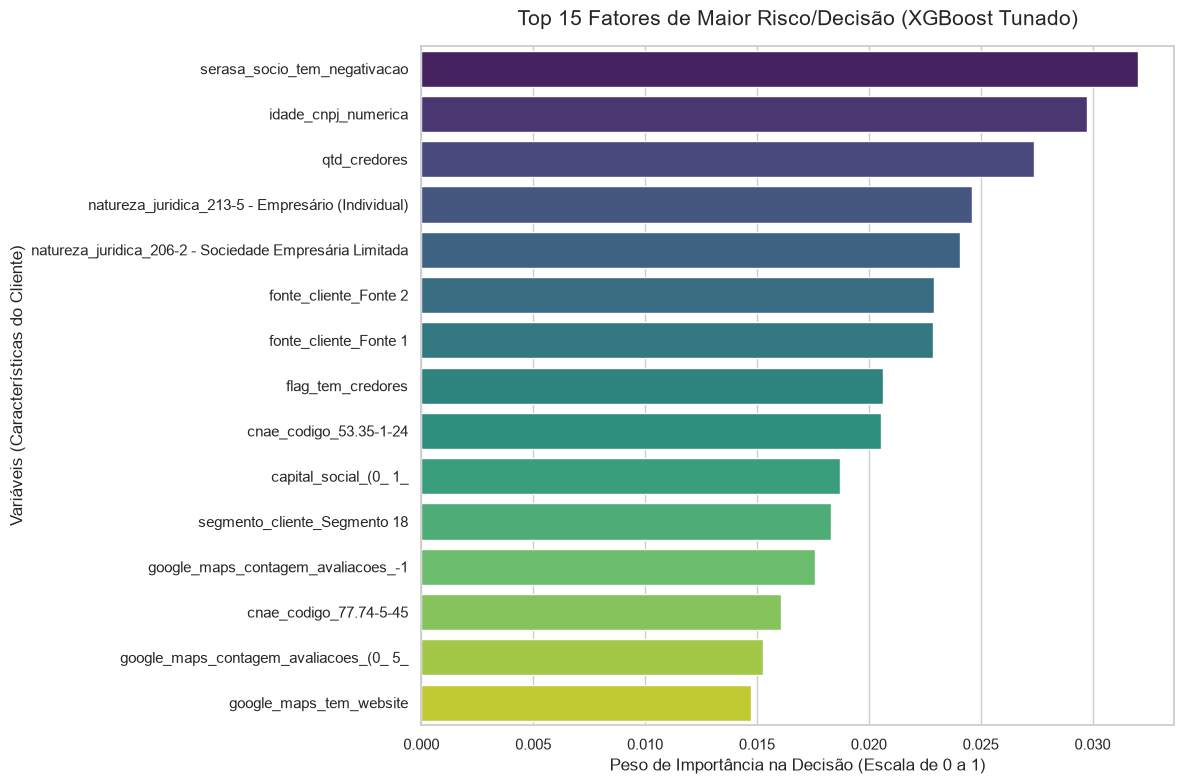

In [ ]:
importancias = xgb_tunado.feature_importances_
variaveis = X_train.columns

df_importancia = pd.DataFrame({
    'Variavel': variaveis,
    'Importancia': importancias
})


df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

top_15_features = df_importancia.head(15)


plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_15_features,
    x='Importancia',
    y='Variavel',
    palette='viridis' 
)


plt.title('Top 15 Fatores de Maior Risco/Decisão', fontsize=15, pad=15)
plt.xlabel('Peso de Importância na Decisão (Escala de 0 a 1)', fontsize=12)
plt.ylabel('Variáveis (Características do Cliente)', fontsize=12)

plt.tight_layout() 
plt.show()

### 8.1. Conclusões Finais: O Perfil do Risco na Praso

A análise de Feature Importance do nosso modelo XGBoost revelou a "caixa preta" das decisões do algoritmo. O gráfico demonstra claramente que o risco de crédito na plataforma não é ditado por um único fator, mas por uma combinação de histórico financeiro, maturidade da empresa e estruturação do negócio.

**Principais Alavancas de Risco Identificadas:**

1. **O Peso Incontestável da Serasa (1º e 3º lugares):** A variável `serasa_socio_tem_negativacao` assumiu a liderança absoluta, seguida de perto pela `qtd_credores` (que nós criamos na Engenharia de Atributos). Isso prova que o comportamento financeiro do sócio (Pessoa Física) e a complexidade de suas dívidas atuais são os maiores termômetros de que a empresa (Pessoa Jurídica) dará calote na Praso.
2. **A Maturidade do Negócio (2º lugar):** A `idade_cnpj_numerica` confirmou a nossa hipótese da EDA. O tempo de existência da empresa é um fator crucial de estabilidade. Modelos de negócios recentes ou recém-abertos apresentam um risco inerentemente diferente de empresas já consolidadas no mercado.
3. **Estrutura Jurídica e Origem:** Variáveis como a Natureza Jurídica (Empresário Individual vs. Sociedade Limitada) e a Fonte de Captação do cliente demonstraram alto impacto. Isso sugere que o nível de formalização da empresa afeta o compromisso com o pagamento.
4. **Presença Digital Preditiva:** De forma fascinante, o tratamento que demos aos valores nulos (`-1`) nas variáveis do Google Maps provou seu valor. A ausência de avaliações no Google (`Maps_contagem_avaliacoes_-1`) apareceu no Top 15. O algoritmo aprendeu que empresas "fantasmas" digitalmente carregam uma propensão diferente de risco.

**Veredito Final do Projeto:**
O desenvolvimento deste modelo preditivo entrega à Praso uma ferramenta robusta e automatizada. Ao unir um motor de **Aprovação de Novos Clientes** (baseado em Serasa e CNPJ) com as descobertas do **Modelo Comportamental** (que provou o alto valor preditivo do atraso médio passado), a Praso agora possui a inteligência de dados necessária para reduzir drasticamente a sua PDD (Provisão para Devedores Duvidosos) sem sacrificar a expansão saudável da sua base de clientes.